# COMP9417 Project — Adult Income Dataset
## xRFM vs XGBoost vs MLP on Binary Classification

### Sections
1. Imports and Setup
2. Data Loading
3. Preprocessing
4. Train/Val/Test Split
5. Model Training — xRFM
6. Model Training — XGBoost
7. Model Training — MLP
8. Results
9. Interpretability Comparison
10. Figures

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

# Data
from ucimlrepo import fetch_ucirepo

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from xrfm import xRFM
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import roc_auc_score, accuracy_score

# Interpretability
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("imports done")

imports done


In [3]:
# Load Adult Income dataset from UCI
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature names:", list(X.columns))
print("\nTarget distribution:\n", y.value_counts())
print("\nMissing values:\n", X.isnull().sum())
print("\nFirst 5 rows:")
X.head()

X shape: (48842, 14)
y shape: (48842, 1)

Feature names: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Target distribution:
 income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Missing values:
 age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

First 5 rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [4]:
# Copy to avoid modifying original
X_clean = X.copy()
y_clean = y.copy()

# --- Target cleaning ---
# Standardise the four target variants into two
y_clean['income'] = y_clean['income'].str.strip().str.replace('.', '', regex=False)
print("Target distribution after cleaning:\n", y_clean['income'].value_counts())

# Binary encode: 1 = >50K, 0 = <=50K
y_clean['income'] = (y_clean['income'] == '>50K').astype(int)
print("\nBinary target distribution:\n", y_clean['income'].value_counts())

# --- Drop redundant/non-predictive columns ---
X_clean = X_clean.drop(columns=['education', 'fnlwgt'])

# --- Replace missing value placeholders ---
X_clean = X_clean.replace('?', np.nan)
# Fill categorical NaNs with 'Unknown'
cat_cols = X_clean.select_dtypes(include='object').columns
X_clean[cat_cols] = X_clean[cat_cols].fillna('Unknown')

print("\nMissing values after cleaning:\n", X_clean.isnull().sum())
print("\nRemaining features:", list(X_clean.columns))

Target distribution after cleaning:
 income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Binary target distribution:
 income
0    37155
1    11687
Name: count, dtype: int64

Missing values after cleaning:
 age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

Remaining features: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [5]:
# --- One-hot encode categorical features ---
X_encoded = pd.get_dummies(X_clean, drop_first=False)
print("Shape after one-hot encoding:", X_encoded.shape)
print("Feature names after encoding:", list(X_encoded.columns))

# --- Z-score normalise numerical features ---
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print("\nNumerical features scaled.")
print("\nSample of scaled data:")
X_encoded[num_cols].describe().round(3)

Shape after one-hot encoding: (48842, 91)
Feature names after encoding: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital-status_Divorced', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Adm-clerical', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'occupa

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000,48842.000,48842.000,48842.000,48842.000
mean,0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.579,-3.531,-0.145,-0.217,-3.181
25%,-0.776,-0.419,-0.145,-0.217,-0.034
50%,-0.120,-0.030,-0.145,-0.217,-0.034
75%,0.682,0.748,-0.145,-0.217,0.369
max,3.746,2.303,13.274,10.592,4.727


In [6]:
# Convert target to array
y_array = y_clean['income'].values

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_array,
    test_size=0.4,
    random_state=SEED,
    stratify=y_array
)

# Second split: 50% of temp = 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print("Train size:", X_train.shape)
print("Val size:  ", X_val.shape)
print("Test size: ", X_test.shape)

# Verify class balance is preserved
print("\nClass balance:")
print(f"  Train:  {y_train.mean():.3f} positive rate")
print(f"  Val:    {y_val.mean():.3f} positive rate")
print(f"  Test:   {y_test.mean():.3f} positive rate")

Train size: (29305, 91)
Val size:   (9768, 91)
Test size:  (9769, 91)

Class balance:
  Train:  0.239 positive rate
  Val:    0.239 positive rate
  Test:   0.239 positive rate


In [7]:
# Convert to numpy arrays for xRFM
X_train_np = X_train.values.astype(float)
X_val_np = X_val.values.astype(float)
X_test_np = X_test.values.astype(float)

# Initialise xRFM
xrfm_model = xRFM(classification=True, random_state=SEED)

# Train with timing
print("Training xRFM...")
t0 = time.time()
xrfm_model.fit(X_train_np, y_train, X_val_np, y_val)
xrfm_train_time = time.time() - t0
print(f"Training time: {xrfm_train_time:.2f}s")

# Inference with timing
print("Running inference...")
t0 = time.time()
xrfm_preds = xrfm_model.predict(X_test_np)
xrfm_probs = xrfm_model.predict_proba(X_test_np)
xrfm_inference_time = time.time() - t0
xrfm_inference_per_sample = xrfm_inference_time / len(X_test_np)

# Metrics
xrfm_auc = roc_auc_score(y_test, xrfm_probs[:, 1])
xrfm_acc = accuracy_score(y_test, xrfm_preds)

print(f"\n--- xRFM Results ---")
print(f"AUC-ROC:              {xrfm_auc:.4f}")
print(f"Accuracy:             {xrfm_acc:.4f}")
print(f"Train time:           {xrfm_train_time:.2f}s")
print(f"Inference/sample:     {xrfm_inference_per_sample*1000:.4f}ms")

None
Training xRFM...
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|                                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 29305, d: 91, and nval: 9768
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 0: 25.005240201950073 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 1: 23.87488603591919 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 2: 23.433717012405396 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 3: 22.841099977493286 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 4: 22.304199934005737 seconds
Using cheap batch size
Optimal M batch size: 10000


Building trees:   0%|                                                                                                                                                                 | 0/1 [02:18<?, ?it/s]

Tree has no split, stopping training
Training time: 138.73s
Running inference...
Using hard routing for tree prediction


Using hard routing for tree prediction

--- xRFM Results ---
AUC-ROC:              0.8720
Accuracy:             0.8365
Train time:           138.73s
Inference/sample:     0.0657ms


In [8]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

# Initialise XGBoost
xgb_base = XGBClassifier(
    random_state=SEED,
    eval_metric='auc',
    verbosity=0,
    use_label_encoder=False
)

# Random search on validation performance
# We manually evaluate on val set after fitting
best_auc = 0
best_params = None
best_xgb = None

import itertools, random
random.seed(SEED)

# Generate 20 random parameter combinations
keys = list(param_dist.keys())
combinations = []
for _ in range(20):
    combo = {k: random.choice(param_dist[k]) for k in keys}
    combinations.append(combo)

print("Tuning XGBoost on validation set (20 iterations)...")
for i, params in enumerate(combinations):
    model = XGBClassifier(
        **params,
        random_state=SEED,
        eval_metric='auc',
        verbosity=0
    )
    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)
    
    if val_auc > best_auc:
        best_auc = val_auc
        best_params = params
        best_xgb = model
    
    if (i+1) % 5 == 0:
        print(f"  Iteration {i+1}/20, best val AUC so far: {best_auc:.4f}")

print(f"\nBest params: {best_params}")
print(f"Best val AUC: {best_auc:.4f}")

# Final evaluation on test set
print("\nEvaluating on test set...")
t0 = time.time()
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
xgb_preds = best_xgb.predict(X_test)
xgb_inference_time = time.time() - t0
xgb_inference_per_sample = xgb_inference_time / len(X_test)

# Training time with best params
t0 = time.time()
best_xgb.fit(X_train, y_train)
xgb_train_time = time.time() - t0

xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"\n--- XGBoost Results ---")
print(f"AUC-ROC:          {xgb_auc:.4f}")
print(f"Accuracy:         {xgb_acc:.4f}")
print(f"Train time:       {xgb_train_time:.2f}s")
print(f"Inference/sample: {xgb_inference_per_sample*1000:.4f}ms")

Tuning XGBoost on validation set (20 iterations)...
  Iteration 5/20, best val AUC so far: 0.9223
  Iteration 10/20, best val AUC so far: 0.9303
  Iteration 15/20, best val AUC so far: 0.9317
  Iteration 20/20, best val AUC so far: 0.9317

Best params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 1.0}
Best val AUC: 0.9317

Evaluating on test set...

--- XGBoost Results ---
AUC-ROC:          0.9310
Accuracy:         0.8780
Train time:       0.70s
Inference/sample: 0.0030ms


In [9]:
from sklearn.neural_network import MLPClassifier

# Tune learning rate on validation set
learning_rates = [0.0001, 0.001, 0.01]
best_lr_auc = 0
best_lr = None
best_mlp = None

print("Tuning MLP learning rate on validation set...")
for lr in learning_rates:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        learning_rate_init=lr,
        max_iter=200,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp.fit(X_train, y_train)
    val_probs = mlp.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)
    print(f"  lr={lr}: val AUC={val_auc:.4f}")
    
    if val_auc > best_lr_auc:
        best_lr_auc = val_auc
        best_lr = lr
        best_mlp = mlp

print(f"\nBest learning rate: {best_lr}")

# Retrain best MLP and time it properly
print("Retraining best MLP for timing...")
mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=best_lr,
    max_iter=200,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1
)

t0 = time.time()
mlp_final.fit(X_train, y_train)
mlp_train_time = time.time() - t0

# Inference timing
t0 = time.time()
mlp_probs = mlp_final.predict_proba(X_test)[:, 1]
mlp_preds = mlp_final.predict(X_test)
mlp_inference_time = time.time() - t0
mlp_inference_per_sample = mlp_inference_time / len(X_test)

mlp_auc = roc_auc_score(y_test, mlp_probs)
mlp_acc = accuracy_score(y_test, mlp_preds)

print(f"\n--- MLP Results ---")
print(f"AUC-ROC:          {mlp_auc:.4f}")
print(f"Accuracy:         {mlp_acc:.4f}")
print(f"Train time:       {mlp_train_time:.2f}s")
print(f"Inference/sample: {mlp_inference_per_sample*1000:.4f}ms")

Tuning MLP learning rate on validation set...
  lr=0.0001: val AUC=0.9145
  lr=0.001: val AUC=0.9157
  lr=0.01: val AUC=0.9147

Best learning rate: 0.001
Retraining best MLP for timing...

--- MLP Results ---
AUC-ROC:          0.9128
Accuracy:         0.8589
Train time:       3.05s
Inference/sample: 0.0020ms


Subsample sizes: [1465, 2930, 5861, 11722, 17583, 23444, 29305]

--- n = 1465 ---
  Training xRFM...
None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|                                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 1465, d: 91, and nval: 9768
Using cheap batch size
Optimal M batch size: 1465
Time taken for round 0: 0.09251570701599121 seconds
Using cheap batch size
Optimal M batch size: 1465
Time taken for round 1: 0.040313720703125 seconds
Using cheap batch size
Optimal M batch size: 1465
Time taken for round 2: 0.03649711608886719 seconds
Using cheap batch size
Optimal M batch size: 1465


Building trees:   0%|                                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

Time taken for round 3: 0.041068077087402344 seconds
Using cheap batch size
Optimal M batch size: 1465
Time taken for round 4: 0.034854888916015625 seconds
Using cheap batch size
Optimal M batch size: 1465
Tree has no split, stopping training
Using hard routing for tree prediction
  xRFM  -- AUC: 0.8661, Time: 0.29s
  Training XGBoost...


...

Building trees:   0%|                                                                                                                                                                 | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 29305, d: 91, and nval: 9768
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 0: 25.64452075958252 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 1: 23.01366400718689 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 2: 23.119351863861084 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 3: 22.54239010810852 seconds
Using cheap batch size
Optimal M batch size: 10000
Time taken for round 4: 21.73446798324585 seconds
Using cheap batch size
Optimal M batch size: 10000


Building trees:   0%|                                                                                                                                                                 | 0/1 [02:18<?, ?it/s]

Tree has no split, stopping training
Using hard routing for tree prediction


  xRFM  -- AUC: 0.8720, Time: 138.50s
  Training XGBoost...
  XGBoost -- AUC: 0.9310, Time: 0.38s
  Training MLP...
  MLP   -- AUC: 0.9128, Time: 2.54s

Scalability runs complete.


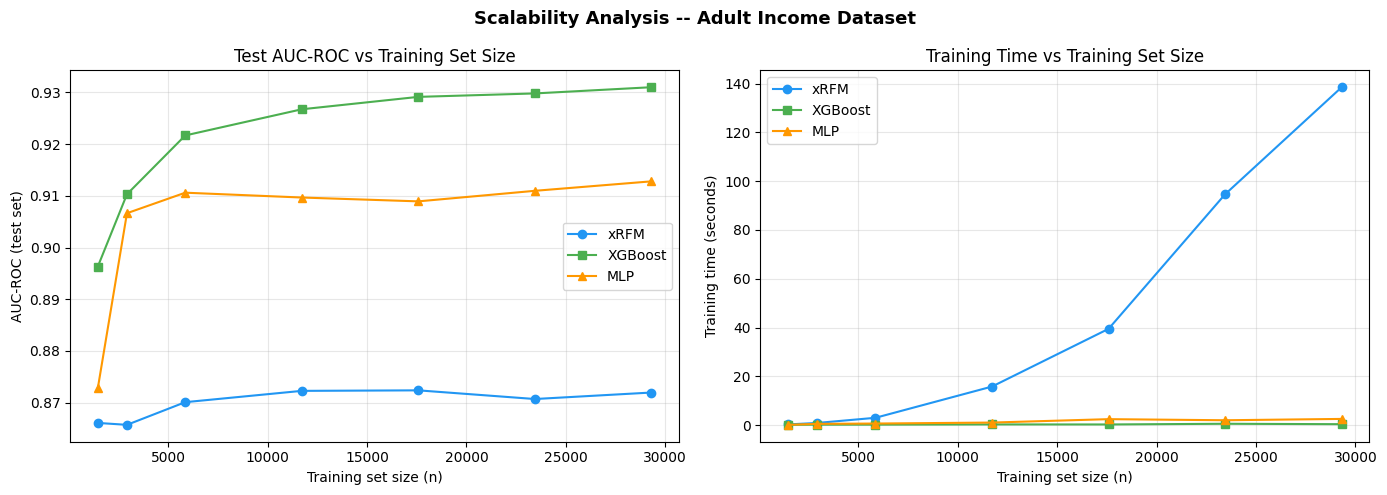

Saved scalability_plot.png


In [10]:
# ============================================================
# Scalability Analysis — Adult Income Dataset
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from xrfm import xRFM
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

n_total = len(X_train)
subsample_sizes = [
    int(n_total * frac)
    for frac in [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
]
print("Subsample sizes:", subsample_sizes)

results_scalability = {
    'n': [],
    'xrfm_auc': [], 'xrfm_time': [],
    'xgb_auc':  [], 'xgb_time':  [],
    'mlp_auc':  [], 'mlp_time':  [],
}

for n in subsample_sizes:
    print(f"\n--- n = {n} ---")

    if n < n_total:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train,
            train_size=n,
            random_state=SEED,
            stratify=y_train
        )
    else:
        X_sub, y_sub = X_train, y_train

    X_sub_np = X_sub.values.astype(float) if hasattr(X_sub, 'values') else X_sub.astype(float)

    # --- xRFM ---
    print("  Training xRFM...")
    xrfm_s = xRFM(classification=True, random_state=SEED)
    t0 = time.time()
    xrfm_s.fit(X_sub_np, y_sub, X_val_np, y_val)
    xrfm_t = time.time() - t0
    xrfm_auc_s = roc_auc_score(y_test, xrfm_s.predict_proba(X_test_np)[:, 1])
    print(f"  xRFM  -- AUC: {xrfm_auc_s:.4f}, Time: {xrfm_t:.2f}s")

    # --- XGBoost ---
    print("  Training XGBoost...")
    xgb_s = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=1.0, random_state=SEED, eval_metric='logloss', verbosity=0
    )
    t0 = time.time()
    xgb_s.fit(X_sub_np, y_sub)
    xgb_t = time.time() - t0
    xgb_auc_s = roc_auc_score(y_test, xgb_s.predict_proba(X_test_np)[:, 1])
    print(f"  XGBoost -- AUC: {xgb_auc_s:.4f}, Time: {xgb_t:.2f}s")

    # --- MLP ---
    print("  Training MLP...")
    mlp_s = MLPClassifier(
        hidden_layer_sizes=(128, 64), learning_rate_init=0.001,
        early_stopping=True, random_state=SEED, max_iter=200
    )
    t0 = time.time()
    mlp_s.fit(X_sub_np, y_sub)
    mlp_t = time.time() - t0
    mlp_auc_s = roc_auc_score(y_test, mlp_s.predict_proba(X_test_np)[:, 1])
    print(f"  MLP   -- AUC: {mlp_auc_s:.4f}, Time: {mlp_t:.2f}s")

    results_scalability['n'].append(n)
    results_scalability['xrfm_auc'].append(xrfm_auc_s)
    results_scalability['xrfm_time'].append(xrfm_t)
    results_scalability['xgb_auc'].append(xgb_auc_s)
    results_scalability['xgb_time'].append(xgb_t)
    results_scalability['mlp_auc'].append(mlp_auc_s)
    results_scalability['mlp_time'].append(mlp_t)

print("\nScalability runs complete.")

# ============================================================
# Plot
# ============================================================

ns = results_scalability['n']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scalability Analysis -- Adult Income Dataset', fontsize=13, fontweight='bold')

ax1.plot(ns, results_scalability['xrfm_auc'], marker='o', label='xRFM',    color='#2196F3')
ax1.plot(ns, results_scalability['xgb_auc'],  marker='s', label='XGBoost', color='#4CAF50')
ax1.plot(ns, results_scalability['mlp_auc'],  marker='^', label='MLP',     color='#FF9800')
ax1.set_xlabel('Training set size (n)')
ax1.set_ylabel('AUC-ROC (test set)')
ax1.set_title('Test AUC-ROC vs Training Set Size')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ns, results_scalability['xrfm_time'], marker='o', label='xRFM',    color='#2196F3')
ax2.plot(ns, results_scalability['xgb_time'],  marker='s', label='XGBoost', color='#4CAF50')
ax2.plot(ns, results_scalability['mlp_time'],  marker='^', label='MLP',     color='#FF9800')
ax2.set_xlabel('Training set size (n)')
ax2.set_ylabel('Training time (seconds)')
ax2.set_title('Training Time vs Training Set Size')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scalability_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved scalability_plot.png")

In [11]:
# ============================================================
# Interpretability Comparison
# AGOP diagonal vs PCA loadings vs MI vs Permutation Importance
# ============================================================

feature_names = list(X_encoded.columns)

# --- 1. Mutual Information ---
print("Computing mutual information...")
mi_scores = mutual_info_classif(X_train, y_train, random_state=SEED)

# --- 2. PCA loadings ---
print("Computing PCA loadings...")
pca = PCA(n_components=1, random_state=SEED)
pca.fit(X_train)
pca_loadings = np.abs(pca.components_[0])

# --- 3. Permutation Importance ---
print("Computing permutation importance (may take a few minutes)...")
t0 = time.time()
perm = permutation_importance(
    best_xgb,  # use XGBoost as it's faster than xRFM for this
    X_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring='roc_auc'
)
perm_scores = perm.importances_mean
print(f"Done in {time.time()-t0:.1f}s")

# --- 4. AGOP diagonal ---
print("Extracting AGOP diagonal...")
# Access the leaf RFM's feature matrix
# xRFM stores the AGOP as the feature matrix M at each leaf
try:
    # Get the root/only leaf since no splits occurred
    leaf_model = xrfm_model.tree_.rfm
    agop_matrix = leaf_model.M  # feature matrix M is the AGOP
    agop_diag = np.diag(agop_matrix)
    print("AGOP diagonal extracted successfully")
except Exception as e:
    print(f"Error extracting AGOP: {e}")
    print("Trying alternative access method...")
    print(dir(xrfm_model))

Computing mutual information...
Computing PCA loadings...
Computing permutation importance (may take a few minutes)...
Done in 13.0s
Extracting AGOP diagonal...
Error extracting AGOP: 'xRFM' object has no attribute 'tree_'
Trying alternative access method...
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_average_M_across_leaves', '_base_max_leaf_size', '_build_leaf_models_from_param_trees', '_build_tree', '_build_tree_cache', '_build_tree_with_iterations', '_collect_attr', '_collect_leaf_nodes', '_ensure_tree_cache', '_generate_projection_from_M', '_generate_random_projection', '_get_agop_on_subset', '_get_balanced_split', '_get_lea

In [12]:
# Probe the xRFM internals to find the AGOP
print("Trying collect_best_agops...")
try:
    agops = xrfm_model.collect_best_agops()
    print("Type:", type(agops))
    print("Length:", len(agops))
    print("First element type:", type(agops[0]))
    print("First element shape:", agops[0].shape if hasattr(agops[0], 'shape') else "no shape")
except Exception as e:
    print(f"Error: {e}")

print("\nTrying models...")
try:
    print("Type:", type(xrfm_model.models))
    print("Length:", len(xrfm_model.models))
    print("First element:", type(xrfm_model.models[0]))
    print("First element attrs:", dir(xrfm_model.models[0]))
except Exception as e:
    print(f"Error: {e}")

Trying collect_best_agops...
Type: <class 'list'>
Length: 1
First element type: <class 'torch.Tensor'>
First element shape: torch.Size([91, 91])

Trying models...
Type: <class 'NoneType'>
Error: object of type 'NoneType' has no len()


In [13]:
import torch

# --- Extract AGOP diagonal ---
agop_matrix = xrfm_model.collect_best_agops()[0]  # shape [91, 91]
agop_diag = torch.diag(agop_matrix).numpy()
print("AGOP diagonal extracted, shape:", agop_diag.shape)

# --- Normalise all scores to [0,1] for fair comparison ---
def normalise(scores):
    r = scores - scores.min()
    if r.max() == 0:
        return r
    return r / r.max()

agop_norm = normalise(agop_diag)
mi_norm = normalise(mi_scores)
pca_norm = normalise(pca_loadings)
perm_norm = normalise(perm_scores.clip(0))  # clip negatives to 0

# --- Build comparison dataframe ---
importance_df = pd.DataFrame({
    'feature': feature_names,
    'AGOP': agop_norm,
    'MI': mi_norm,
    'PCA': pca_norm,
    'Permutation': perm_norm
})

# --- Top 15 features by AGOP ---
top15_agop = importance_df.nlargest(15, 'AGOP')
print("\nTop 15 features by AGOP diagonal:")
print(top15_agop.to_string(index=False))

# --- Top 15 features by MI ---
top15_mi = importance_df.nlargest(15, 'MI')
print("\nTop 15 features by Mutual Information:")
print(top15_mi[['feature', 'MI']].to_string(index=False))

# --- Save full results ---
importance_df.to_csv('adult_income_interpretability.csv', index=False)
print("\nSaved to adult_income_interpretability.csv")

AGOP diagonal extracted, shape: (91,)

Top 15 features by AGOP diagonal:
                          feature     AGOP       MI      PCA  Permutation
                              age 1.000000 0.601287 0.976343     0.536254
                   hours-per-week 0.139530 0.353199 1.000000     0.170607
                    education-num 0.042403 0.627107 0.753167     0.370019
                     capital-gain 0.039254 0.778594 0.536211     0.771291
            native-country_France 0.031344 0.000000 0.000211     0.000015
              native-country_Laos 0.021718 0.003469 0.000169     0.000000
marital-status_Married-civ-spouse 0.018981 1.000000 0.477526     1.000000
                relationship_Wife 0.017054 0.074957 0.003191     0.036881
            workclass_Without-pay 0.016953 0.008758 0.000005     0.000119
          native-country_Columbia 0.016512 0.000000 0.000660     0.002606
            native-country_Canada 0.016026 0.019911 0.001472     0.000694
          occupation_Tech-support 0.012

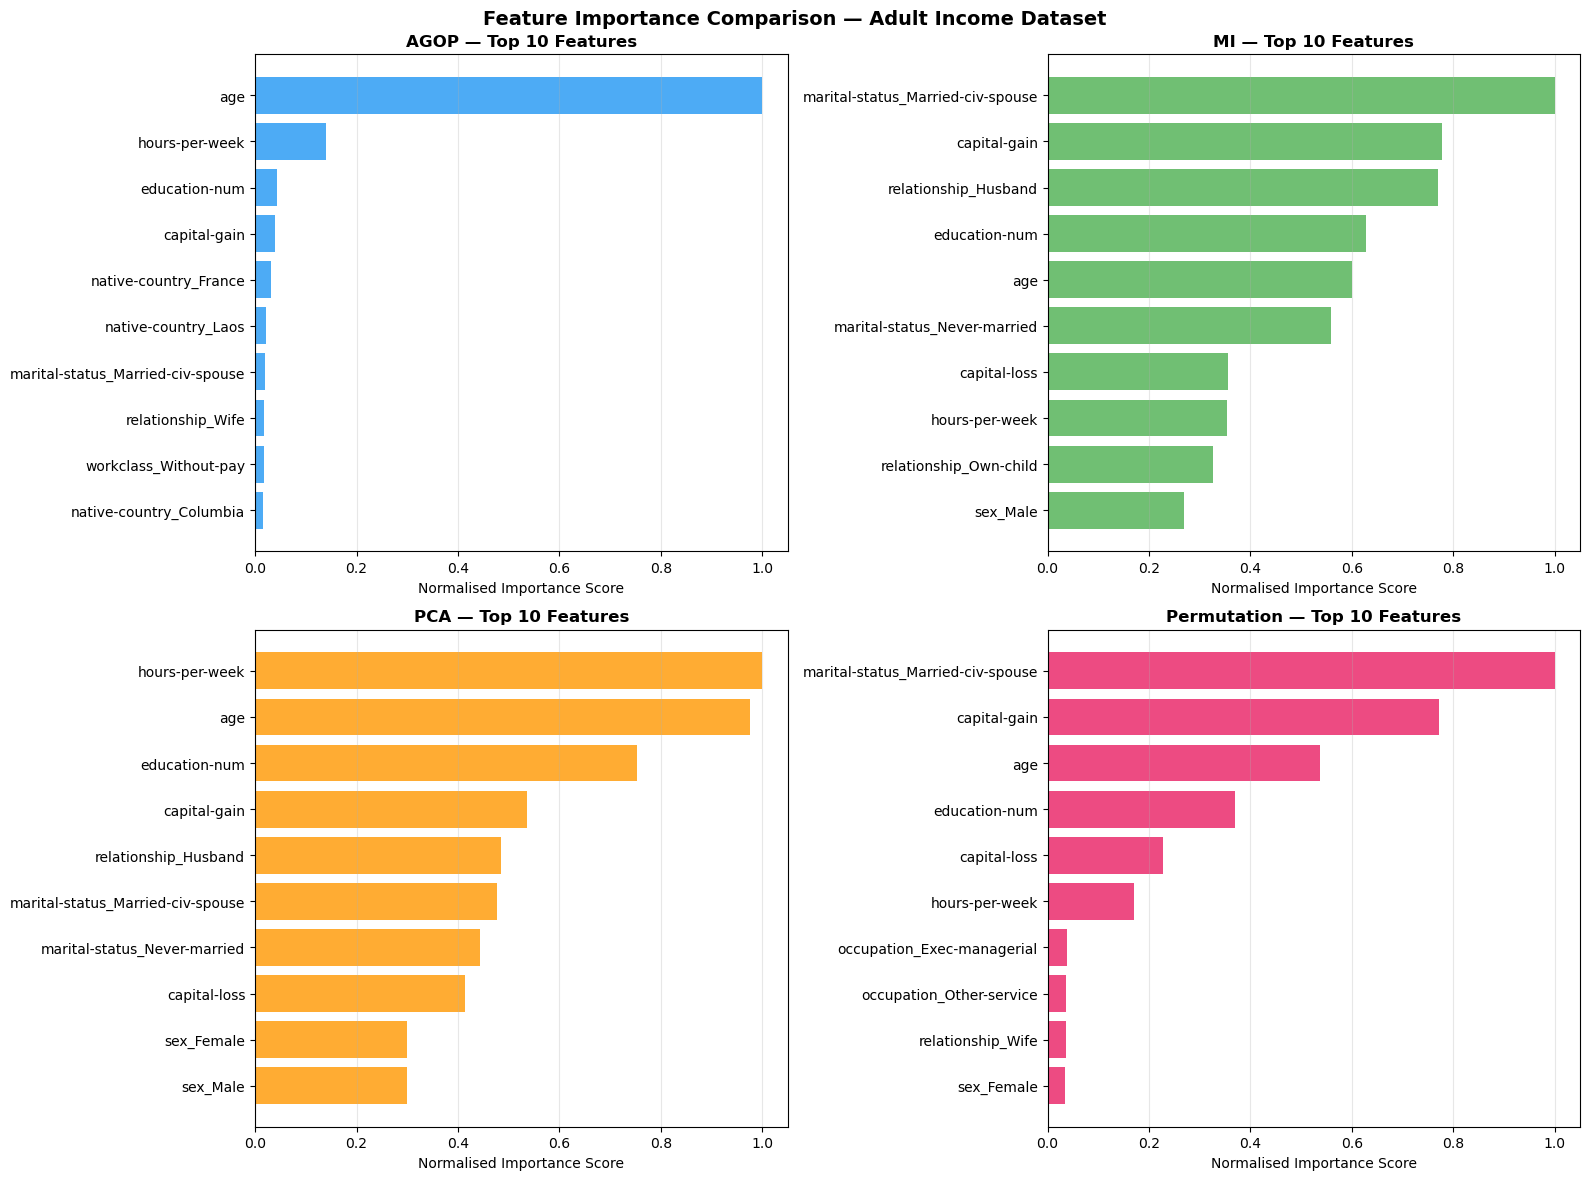

Saved interpretability_comparison.png

--- Spearman Rank Correlation Between Methods ---
              AGOP     MI    PCA  Permutation
AGOP         1.000  0.240  0.195        0.508
MI           0.240  1.000  0.716        0.479
PCA          0.195  0.716  1.000        0.629
Permutation  0.508  0.479  0.629        1.000


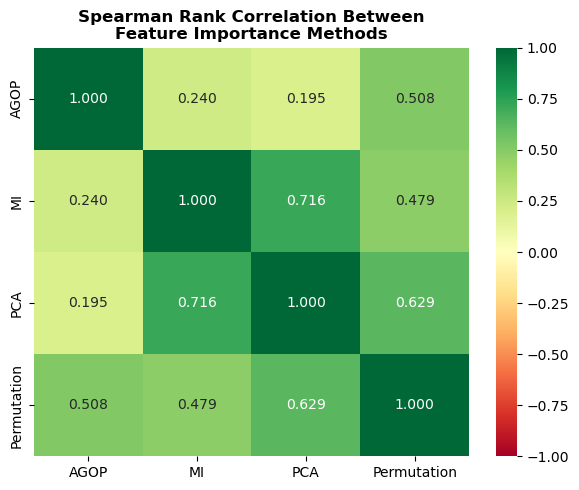

Saved rank_correlation_heatmap.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Importance Comparison — Adult Income Dataset', 
             fontsize=14, fontweight='bold')

methods = ['AGOP', 'MI', 'PCA', 'Permutation']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
axes_flat = axes.flatten()

for ax, method, color in zip(axes_flat, methods, colors):
    top10 = importance_df.nlargest(10, method)
    ax.barh(top10['feature'], top10[method], color=color, alpha=0.8)
    ax.set_title(f'{method} — Top 10 Features', fontweight='bold')
    ax.set_xlabel('Normalised Importance Score')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('interpretability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved interpretability_comparison.png")

# --- Rank correlation between methods ---
print("\n--- Spearman Rank Correlation Between Methods ---")
from scipy.stats import spearmanr

methods_data = importance_df[['AGOP', 'MI', 'PCA', 'Permutation']].values
method_names = ['AGOP', 'MI', 'PCA', 'Permutation']

corr_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
for i, m1 in enumerate(method_names):
    for j, m2 in enumerate(method_names):
        corr, _ = spearmanr(importance_df[m1], importance_df[m2])
        corr_matrix.loc[m1, m2] = round(corr, 3)

print(corr_matrix)

# --- Heatmap of rank correlations ---
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            ax=ax)
ax.set_title('Spearman Rank Correlation Between\nFeature Importance Methods', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('rank_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved rank_correlation_heatmap.png")

In [15]:
# ============================================================
# Final Results Summary
# ============================================================

results = {
    'Model': ['xRFM', 'XGBoost', 'MLP'],
    'AUC-ROC': [xrfm_auc, xgb_auc, mlp_auc],
    'Accuracy': [xrfm_acc, xgb_acc, mlp_acc],
    'Train_Time_s': [xrfm_train_time, xgb_train_time, mlp_train_time],
    'Inference_ms_per_sample': [
        xrfm_inference_per_sample * 1000,
        xgb_inference_per_sample * 1000,
        mlp_inference_per_sample * 1000
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("=== Adult Income — Final Results ===")
print(results_df.to_string(index=False))

results_df.to_csv('adult_income_results.csv', index=False)
print("\nSaved to adult_income_results.csv")

# --- Summary of interpretability findings ---
print("\n=== Top 5 Features by Each Method ===")
for method in ['AGOP', 'MI', 'PCA', 'Permutation']:
    top5 = importance_df.nlargest(5, method)['feature'].tolist()
    print(f"{method:15}: {top5}")

print("\n=== Spearman Rank Correlations ===")
print(corr_matrix)

=== Adult Income — Final Results ===
  Model  AUC-ROC  Accuracy  Train_Time_s  Inference_ms_per_sample
   xRFM   0.8705    0.8384      160.2440                   0.0799
XGBoost   0.9310    0.8780        1.0947                   0.0027
    MLP   0.9128    0.8589       59.1547                   0.0052

Saved to adult_income_results.csv

=== Top 5 Features by Each Method ===
AGOP           : ['age', 'hours-per-week', 'education-num', 'capital-gain', 'native-country_France']
MI             : ['marital-status_Married-civ-spouse', 'capital-gain', 'relationship_Husband', 'education-num', 'age']
PCA            : ['hours-per-week', 'age', 'education-num', 'capital-gain', 'relationship_Husband']
Permutation    : ['marital-status_Married-civ-spouse', 'capital-gain', 'age', 'education-num', 'capital-loss']

=== Spearman Rank Correlations ===
              AGOP     MI    PCA  Permutation
AGOP         1.000  0.240  0.195        0.508
MI           0.240  1.000  0.716        0.479
PCA          0.195  